
# Análise Exploratória dos Dados (EDA) — Online Retail

**Objetivo:** compreender a estrutura do dataset *Online Retail*, quantificar qualidade/limpeza, caracterizar a **cauda longa** (long tail) e **esparsidade** (fundamentais em sistemas de recomendação), inspecionar o conteúdo textual de `Description` (base para conteúdo/TF‑IDF), analisar padrões temporais (visando *split* sem vazamento), e **deixar pronto** o material para modelagem (CF item–item, conteúdo e blending).

**Sumário do notebook**
1. Carregamento e visão geral  
2. Limpeza e padronização  
3. **Tabela ANTES vs. DEPOIS**  
4. Distribuições e cauda longa (usuário/item) + *cold‑start*  
5. Esparsidade/Densidade da matriz usuário–item  
6. Análise temporal + **split temporal** (treino/teste)  
7. Texto: qualidade e TF‑IDF com termos genéricos filtrados  
8. Heatmap `weekday × hour` (sinal contextual)  
9. Salvamento de artefatos para a modelagem


## 1) Carregamento e visão geral

Primeiro carregamos o arquivo Excel usando `pandas.read_excel` e verificamos as primeiras linhas para entender os campos disponíveis. As colunas importantes são:

* **InvoiceNo** – identificador da fatura;
* **StockCode** – identificador do item;
* **Description** – descrição textual do item;
* **Quantity** – quantidade de unidades compradas;
* **InvoiceDate** – data e hora da compra;
* **UnitPrice** – preço unitário;
* **CustomerID** – identificador do cliente;
* **Country** – país de origem do cliente.

In [23]:

# Install openpyxl so pandas can read .xlsx files in this notebook environment
%pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminho do arquivo (ajuste se necessário)
file_path = "../data/raw/Online Retail.xlsx"

# Leitura
df = pd.read_excel(file_path, sheet_name="Online Retail")

print("Primeiras linhas:")
display(df.head())

print("\nInformações gerais do DataFrame:")
print(df.info())

print("\nValores nulos por coluna:")
print(df.isnull().sum())

print("\nEstatísticas descritivas (variáveis numéricas):")
display(df[['Quantity','UnitPrice']].describe())

print("\nIntervalo temporal bruto:")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
print(df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Primeiras linhas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Valores nulos por coluna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Estatísticas descritivas (variáveis numéricas):


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000



Intervalo temporal bruto:
2010-12-01 08:26:00 → 2011-12-09 12:50:00


## 2) Limpeza e padronização

In [24]:
# Normalização de tipos e espaços
df['StockCode'] = df['StockCode'].astype(str).str.strip()
# Credit notes (cancelamentos/devoluções) têm InvoiceNo iniciando com 'C'
mask_credit = df['InvoiceNo'].astype(str).str.startswith('C', na=False)

# Keep: cliente identificado + quantidades e preços positivos + não-credit-note
df1 = (df
       .loc[~mask_credit]
       .loc[df['CustomerID'].notna()]
       .loc[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
       .copy())

# Remove duplicatas exatas (se existirem)
subset_cols = ['InvoiceNo','StockCode','CustomerID','Quantity','UnitPrice','InvoiceDate']
df1 = df1.drop_duplicates(subset=subset_cols)

codes = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK', 'C2']
df1 = df1[~df1['StockCode'].isin(codes)]

# Normaliza Description
df1['Description'] = df1['Description'].fillna('').str.strip()

df_clean = df1.reset_index(drop=True)


print("Shape df_clean:", df_clean.shape)
print("#Clientes:", df_clean['CustomerID'].nunique(), "| #Itens:", df_clean['StockCode'].nunique())
print("Intervalo temporal limpo:", df_clean['InvoiceDate'].min(), "→", df_clean['InvoiceDate'].max())


Shape df_clean: (391148, 8)
#Clientes: 4334 | #Itens: 3659
Intervalo temporal limpo: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


## 3) Tabela **ANTES vs. DEPOIS** da limpeza

In [25]:

def summary(df_):
    return pd.Series({
        'linhas': len(df_),
        'clientes': df_['CustomerID'].nunique(),
        'itens': df_['StockCode'].nunique(),
        'periodo': f"{pd.to_datetime(df_['InvoiceDate']).min().date()} → {pd.to_datetime(df_['InvoiceDate']).max().date()}",
        'pct_desc_vazia': round(100*(df_['Description'].isna() | (df_['Description'].astype(str).str.strip()=='')).mean(), 2)
    })

print("ANTES:")
display(summary(df).to_frame('valor'))

print("\nDEPOIS:")
display(summary(df_clean).to_frame('valor'))


ANTES:


,valor
linhas,541909
clientes,4372
itens,4070
periodo,2010-12-01 → 2011-12-09
pct_desc_vazia,0.27



DEPOIS:


,valor
linhas,391148
clientes,4334
itens,3659
periodo,2010-12-01 → 2011-12-09
pct_desc_vazia,0.0


## 4) Distribuições (long tail) e *cold‑start*

% usuários com menos de 5 interações: 5.28%  |  % itens com menos de 5 interações: 13.06%
Top 1% itens cobrem 9.79% das compras
Top 5% itens cobrem 30.21% das compras
Top 10% itens cobrem 45.62% das compras


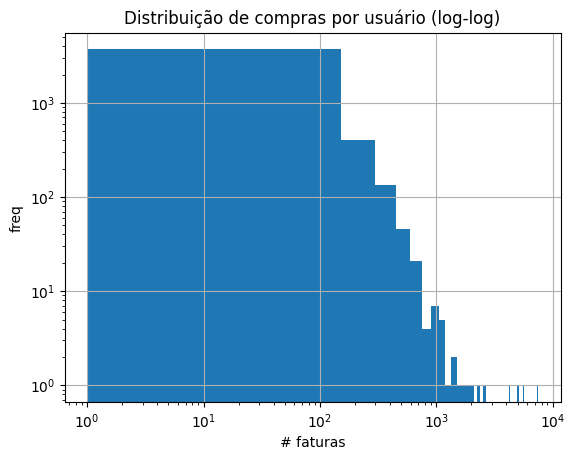

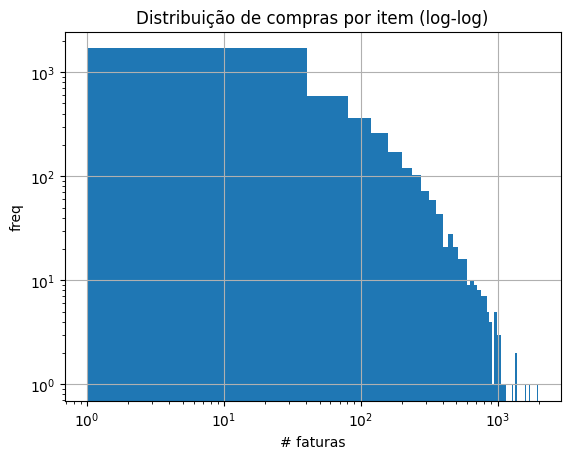

In [26]:

# Contabiliza nº de faturas distintas por par (usuário, item) → aproximação de interação
ui_invoices = (df_clean
               .groupby(['CustomerID','StockCode'])['InvoiceNo']
               .nunique()
               .reset_index(name='n_invoices'))

# Histogramas de atividade
u_hist = ui_invoices.groupby('CustomerID')['n_invoices'].sum()
i_hist = ui_invoices.groupby('StockCode')['n_invoices'].sum()

itens = 5
pct_cold_users = (u_hist<itens).mean()*100
pct_cold_items = (i_hist<itens).mean()*100
print(f"% usuários com menos de {itens} interações: {pct_cold_users:.2f}%  |  % itens com menos de {itens} interações: {pct_cold_items:.2f}%")

# Curva acumulada: cobertura por itens mais populares
i_hist_sorted = i_hist.sort_values(ascending=False)
cum_share = i_hist_sorted.cumsum()/i_hist_sorted.sum()
for p in [0.01, 0.05, 0.10]:
    k = int(np.ceil(p*len(i_hist_sorted)))
    print(f"Top {int(p*100)}% itens cobrem {cum_share.iloc[k-1]*100:.2f}% das compras")

# Gráficos (log-log para visualizar caudas)
plt.figure()
u_hist.hist(bins=50)
plt.xscale('log'); plt.yscale('log')
plt.title('Distribuição de compras por usuário (log-log)')
plt.xlabel('# faturas'); plt.ylabel('freq')
plt.show()

plt.figure()
i_hist.hist(bins=50)
plt.xscale('log'); plt.yscale('log')
plt.title('Distribuição de compras por item (log-log)')
plt.xlabel('# faturas'); plt.ylabel('freq')
plt.show()



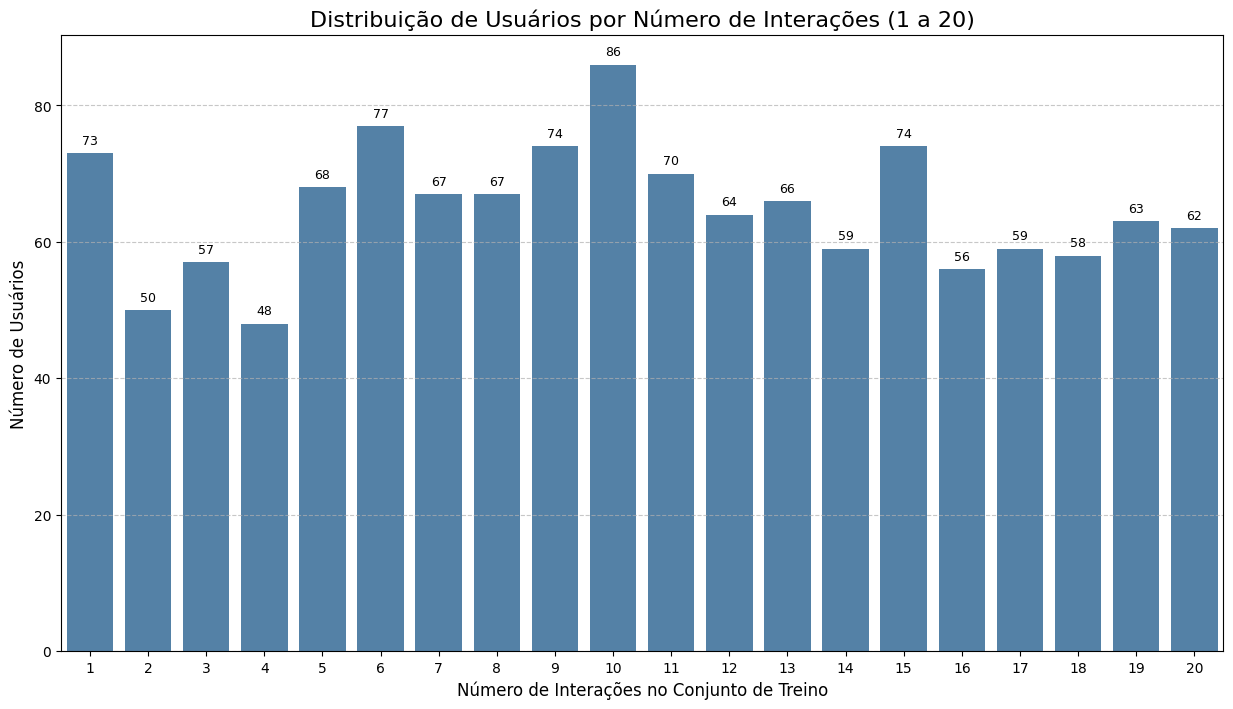

In [27]:
import seaborn as sns

user_interaction_counts = df_clean['CustomerID'].value_counts()
interaction_frequency = user_interaction_counts.value_counts().sort_index()

interaction_frequency.name = 'Numero de Usuarios'
interaction_frequency.index.name = 'Numero de Interacoes'

freq_df = interaction_frequency.reset_index()

# 4. Foque nas contagens mais baixas (ex: de 1 a 20 interações)
#    É difícil visualizar milhares de contagens, o corte está no começo.
K_cutoff = 20
freq_df_plot = freq_df[freq_df['Numero de Interacoes'] <= K_cutoff]

# 5. Crie o Gráfico de Barras
plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=freq_df_plot,
    x='Numero de Interacoes',
    y='Numero de Usuarios',
    color='steelblue'
)

ax.set_title(f'Distribuição de Usuários por Número de Interações (1 a {K_cutoff})', fontsize=16)
ax.set_xlabel('Número de Interações no Conjunto de Treino', fontsize=12)
ax.set_ylabel('Número de Usuários', fontsize=12)

# Adiciona os rótulos de contagem em cima das barras para clareza
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5) Esparsidade/Densidade da matriz usuário–item

In [28]:

n_users = df_clean['CustomerID'].nunique()
n_items = df_clean['StockCode'].nunique()
nnz     = len(ui_invoices)  # pares (u,i) com >=1 fatura
density = nnz / (n_users * n_items)
print(f"Densidade: {100*density:.4f}%  |  Esparsidade: {100*(1-density):.4f}%")


Densidade: 1.6788%  |  Esparsidade: 98.3212%


## 6) Análise temporal e **split temporal** (evitar vazamento)

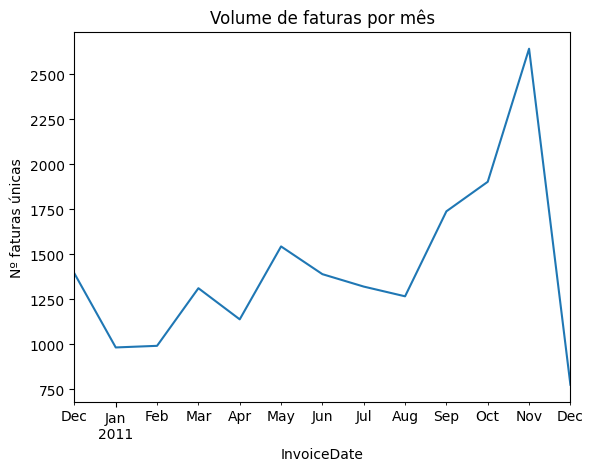

Treino: 01/12/2010 → 09/10/2011 | linhas: 274766
Teste : 09/10/2011 → 09/12/2011 | linhas: 116382


In [29]:

# Série mensal de volume de faturas
df_clean.set_index('InvoiceDate').resample('ME')['InvoiceNo'].nunique().plot(title='Volume de faturas por mês')
plt.ylabel('Nº faturas únicas')
plt.show()

# Split temporal: últimos 2 meses como teste (ajuste conforme projeto)
cutoff = df_clean['InvoiceDate'].max() - pd.DateOffset(months=2)
train_df = df_clean[df_clean['InvoiceDate'] < cutoff].copy()
test_df  = df_clean[df_clean['InvoiceDate'] >= cutoff].copy()

print("Treino:", train_df['InvoiceDate'].min().strftime('%d/%m/%Y'), "→", train_df['InvoiceDate'].max().strftime('%d/%m/%Y'), "| linhas:", len(train_df))
print("Teste :", test_df['InvoiceDate'].min().strftime('%d/%m/%Y'), "→", test_df['InvoiceDate'].max().strftime('%d/%m/%Y'), "| linhas:", len(test_df))


## 7) Texto (`Description`): qualidade e TF‑IDF com termos genéricos filtrados

In [30]:

# Consolida descrições por item e remove termos genéricos
generic_terms = {
    'set','box','assort','pack','gift','bag','kit','mixed',
    'small','medium','large','colour','color','party','assorted'
}

def preprocess_desc(s):
    s = (s or '').lower()
    return ' '.join([w for w in s.split() if w not in generic_terms])

item_desc = (df_clean.groupby('StockCode')['Description']
             .agg(lambda s: preprocess_desc(' '.join(s.dropna().unique())))
             .replace('', np.nan)
             .dropna())

pct_sem_texto = 100*(df_clean.groupby('StockCode')['Description']
                     .apply(lambda s: s.isna().all() or (s.str.strip()=='').all())
                     .mean())
print(f"% de itens sem descrição útil (antes do preprocess): {pct_sem_texto:.2f}%")

# TF-IDF
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(min_df=3, stop_words='english', ngram_range=(1,2))
    X_tfidf = vectorizer.fit_transform(item_desc.values)

    # Top termos globais (por média de TF)
    tf_means = X_tfidf.mean(axis=0).A1
    terms = np.array(vectorizer.get_feature_names_out())
    order = tf_means.argsort()[::-1]
    print("Top 20 termos TF-IDF:\n", terms[order][:50])
except Exception as e:
    print("Aviso: scikit-learn indisponível para TF-IDF. Instale scikit-learn para rodar esta célula.")
    print("Erro:", e)


% de itens sem descrição útil (antes do preprocess): 0.00%
Top 20 termos TF-IDF:
 ['pink' 'blue' 'heart' 'vintage' 'red' 'glass' 'christmas' 'white'
 'design' 'flower' 'metal' 'retrospot' 'light' 'holder' 'candle' 'hanging'
 'black' 'silver' 'decoration' 'rose' 'card' 'green' 'necklace' 'paper'
 'mug' 'wrap' 'cake' 'wall' 'sign' 'garden' 'polkadot' 'cover'
 'light holder' 'bracelet' '12' 'art' 'mini' 'ivory' 'wooden' 'tea' 'bowl'
 'set' 'metal sign' 'red retrospot' 'cushion' 'mirror' 'love' 'egg' 'tree'
 'star']


## 8) Heatmap `weekday × hour` (sinal contextual)

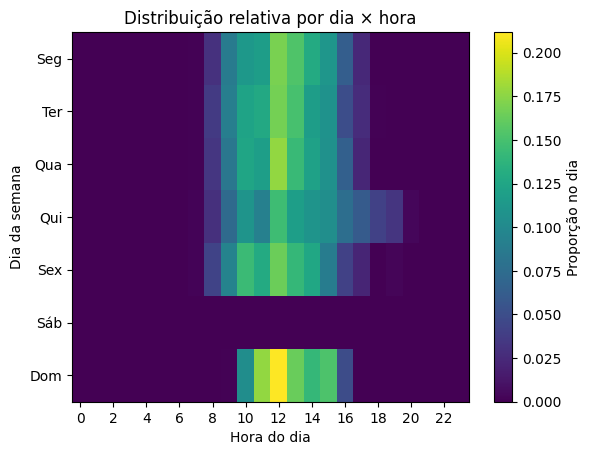

In [31]:

tmp = df_clean.assign(wd=df_clean['InvoiceDate'].dt.dayofweek,
                      hr=df_clean['InvoiceDate'].dt.hour)
pivot = tmp.pivot_table(index='wd', columns='hr', values='InvoiceNo',
                        aggfunc='nunique', fill_value=0)

pivot = pivot.reindex(index=range(7), columns=range(24), fill_value=0)

row_norm = pivot.div(pivot.sum(axis=1).replace(0,1), axis=0)  # evita divisão por zero
labels = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
yticks = list(pivot.index)

plt.imshow(row_norm.values, aspect='auto')
plt.colorbar(label='Proporção no dia')
plt.title('Distribuição relativa por dia × hora')
plt.xlabel('Hora do dia'); 
plt.ylabel('Dia da semana')
plt.yticks(ticks=range(len(yticks)), labels=[labels[i] for i in yticks])
plt.xticks(ticks=range(0,24,2), labels=[str(h) for h in range(0,24,2)])
plt.show()


--- 🔄 Análise de Recompra (Replenishment) ---


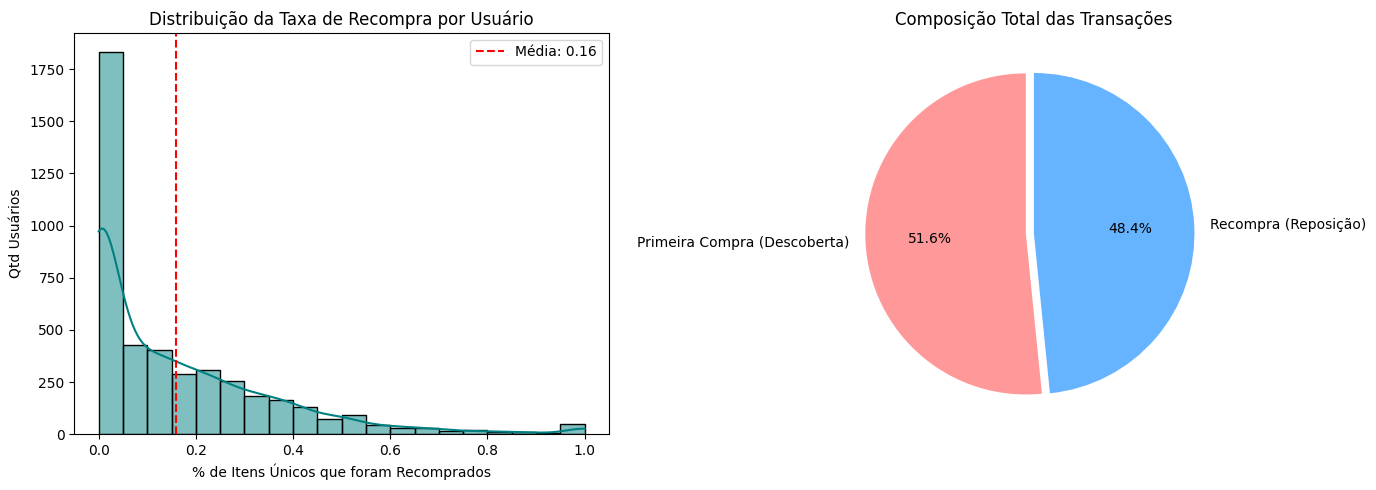

Média de Itens Recomprados por Usuário: 15.99%
Volume Total de Transações que são Recompra: 48.41%


In [32]:
def analyze_repurchase_behavior(df):
    """
    Analisa o comportamento de recompra (B2B) no dataset.
    """
    print("--- 🔄 Análise de Recompra (Replenishment) ---")
    
    # 1. Identificar Recompras
    # Agrupa por Usuário e Item e conta quantos Invoices distintos existem
    user_item_counts = df.groupby(['CustomerID', 'StockCode'])['InvoiceNo'].nunique().reset_index(name='purchase_count')
    
    # Se purchase_count > 1, é um item de recompra para aquele usuário
    user_item_counts['is_repurchase'] = user_item_counts['purchase_count'] > 1
    
    # 2. Métrica 1: Lealdade por Usuário (% do catálogo do usuário que é recompra)
    user_loyalty = user_item_counts.groupby('CustomerID')['is_repurchase'].mean()
    
    # 3. Métrica 2: Impacto no Volume Total (Transações)
    # Trazemos a flag 'is_repurchase' de volta para o dataframe principal (merge)
    df_merged = df.merge(user_item_counts[['CustomerID', 'StockCode', 'is_repurchase']], on=['CustomerID', 'StockCode'], how='left')
    
    # Contamos quantas linhas (transações) são de itens recomprados vs novos
    transacoes_recompra = df_merged['is_repurchase'].value_counts(normalize=True)
    
    # --- PLOTAGEM ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Histograma de Lealdade dos Usuários
    sns.histplot(user_loyalty, bins=20, kde=True, ax=axes[0], color='teal')
    axes[0].set_title('Distribuição da Taxa de Recompra por Usuário')
    axes[0].set_xlabel('% de Itens Únicos que foram Recomprados')
    axes[0].set_ylabel('Qtd Usuários')
    axes[0].axvline(user_loyalty.mean(), color='red', linestyle='--', label=f'Média: {user_loyalty.mean():.2f}')
    axes[0].legend()
    
    # Gráfico 2: Pizza de Volume de Transações
    labels = ['Primeira Compra (Descoberta)', 'Recompra (Reposição)']
    # O value_counts retorna False (Novo) e True (Recompra). Ajustar ordem se necessário.
    sizes = [transacoes_recompra.get(False, 0), transacoes_recompra.get(True, 0)]
    colors = ['#ff9999','#66b3ff']
    
    axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
    axes[1].set_title('Composição Total das Transações')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Média de Itens Recomprados por Usuário: {user_loyalty.mean():.2%}")
    print(f"Volume Total de Transações que são Recompra: {transacoes_recompra.get(True, 0):.2%}")

# Execute passando seu dataframe limpo
analyze_repurchase_behavior(df)

## 10) Salvamento de artefatos para a modelagem

In [33]:

# Artefatos úteis para a etapa de modelagem
df_clean['StockCode'] = df_clean['StockCode'].astype(str)
df_clean.to_parquet("../data/processed/online_retail_clean.parquet", index=False)
ui_invoices.to_parquet("../data/ui_invoices.parquet", index=False)

print("Arquivos salvos:")
print("- /mnt/data/online_retail_clean.parquet")
print("- /mnt/data/ui_invoices.parquet")


Arquivos salvos:
- /mnt/data/online_retail_clean.parquet
- /mnt/data/ui_invoices.parquet
